# Heart Disease Diagnosis using Machine Learning

## 1. Giới thiệu bài toán

Bệnh tim là một trong những vấn đề sức khỏe nghiêm trọng và phổ biến trên thế giới.
Việc phát hiện sớm nguy cơ mắc bệnh tim có thể giúp bác sĩ và bệnh nhân đưa ra các biện pháp điều trị hoặc phòng ngừa kịp thời.

Trong dự án này, chúng ta sử dụng bộ dữ liệu Heart Disease UCI để xây dựng mô hình Machine Learning nhằm dự đoán một bệnh nhân có mắc bệnh tim hay không dựa trên các thông tin y tế như tuổi, giới tính, huyết áp, cholesterol, nhịp tim tối đa, loại đau ngực và một số chỉ số liên quan khác.

## Bối cảnh

Bộ dữ liệu gồm thông tin y tế của các bệnh nhân được thu thập từ nhiều nguồn khác nhau.
Mỗi bệnh nhân có nhiều thuộc tính như tuổi, giới tính, loại đau ngực, huyết áp khi nghỉ, cholesterol, đường huyết, kết quả điện tâm đồ, nhịp tim tối đa và một số thông tin lâm sàng khác.

Biến mục tiêu của bài toán là `num`, thể hiện mức độ mắc bệnh tim của bệnh nhân.

## Tầm quan trọng

Dự đoán bệnh tim bằng Machine Learning có thể hỗ trợ quá trình chẩn đoán ban đầu, giúp phát hiện các bệnh nhân có nguy cơ cao.
Điều này có ý nghĩa trong việc hỗ trợ bác sĩ ra quyết định, tiết kiệm thời gian kiểm tra và nâng cao hiệu quả chăm sóc sức khỏe.

## Mục tiêu dự án

Mục tiêu của dự án là xây dựng mô hình phân loại để dự đoán bệnh nhân có mắc bệnh tim hay không.

Trong bộ dữ liệu gốc, cột `num` có các giá trị từ 0 đến 4:
- `num = 0`: Không mắc bệnh tim
- `num > 0`: Có mắc bệnh tim

Do đó, bài toán sẽ được chuyển thành bài toán phân loại nhị phân:
- `0`: Không mắc bệnh tim
- `1`: Có mắc bệnh tim

## Phương pháp tiếp cận

Đây là bài toán phân loại nhị phân (Binary Classification).
Dự án sẽ thử nghiệm và so sánh ba mô hình Machine Learning:

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

Các mô hình sẽ được đánh giá bằng các thước đo như Accuracy, Precision, Recall, F1-score và Confusion Matrix.

In [ ]:
# Import các thư viện cần thiết cho dự án
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị
pd.set_option('display.max_columns', None)

In [ ]:
# Đọc dữ liệu

df = pd.read_csv('/content/drive/MyDrive/Võ Như Chiến/Python-DUT/Project-ML/heart_disease_uci.csv')

# Hiển thị 5 dòng đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2. Mô tả dữ liệu

Bộ dữ liệu được sử dụng trong dự án là Heart Disease UCI Dataset.
Dataset chứa thông tin y tế của các bệnh nhân, bao gồm các đặc trưng như tuổi, giới tính, loại đau ngực, huyết áp, cholesterol, nhịp tim tối đa, kết quả điện tâm đồ và một số chỉ số liên quan khác.

Mục tiêu của bài toán là dự đoán bệnh nhân có mắc bệnh tim hay không dựa trên các thông tin y tế này.

Trong dataset, cột `num` là biến mục tiêu:
- `num = 0`: Không mắc bệnh tim
- `num > 0`: Có mắc bệnh tim

Ban đầu, cột `num` có nhiều mức độ bệnh từ 0 đến 4.
Trong dự án này, ta chuyển bài toán thành phân loại nhị phân:
- 0: Không mắc bệnh tim
- 1: Có mắc bệnh tim

In [ ]:
# Kiểm tra số dòng và số cột của dữ liệu

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Số dòng: 920
Số cột: 16


In [ ]:
# Xem danh sách các cột trong dataset

for col in df.columns:
    print(col)

id
age
sex
dataset
cp
trestbps
chol
fbs
restecg
thalch
exang
oldpeak
slope
ca
thal
num


Các cột trong dataset bao gồm:

- `id`: Mã định danh duy nhất của từng bệnh nhân.
- `age`: Tuổi của bệnh nhân.
- `sex`: Giới tính của bệnh nhân.
- `dataset`: Nguồn hoặc nơi thu thập dữ liệu.
- `cp`: Loại đau ngực.
- `trestbps`: Huyết áp khi nghỉ.
- `chol`: Lượng cholesterol trong máu.
- `fbs`: Đường huyết lúc đói có lớn hơn 120 mg/dl hay không.
- `restecg`: Kết quả điện tâm đồ khi nghỉ.
- `thalch`: Nhịp tim tối đa đạt được.
- `exang`: Có đau thắt ngực do vận động hay không.
- `oldpeak`: Độ chênh ST khi vận động so với lúc nghỉ.
- `slope`: Độ dốc của đoạn ST khi đạt đỉnh vận động.
- `ca`: Số lượng mạch máu chính được phát hiện qua fluoroscopy.
- `thal`: Tình trạng Thalassemia.
- `num`: Biến mục tiêu, thể hiện tình trạng mắc bệnh tim.

Trong đó, `num` là biến cần dự đoán.  
Các cột còn lại sẽ được sử dụng làm đặc trưng đầu vào cho mô hình, ngoại trừ `id` vì đây chỉ là mã định danh bệnh nhân.

In [ ]:
# Xem thông tin tổng quan: tên cột, số giá trị không null và kiểu dữ liệu

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


Note:

- Dataset có **920 dòng** và **16 cột**.  
Các cột trong dữ liệu gồm cả biến số và biến phân loại.
- Một số cột như `id`, `age`, `sex`, `dataset`, `cp`, `num` không bị thiếu dữ liệu.  
- Tuy nhiên, nhiều cột khác có missing values, đặc biệt là `ca`, `thal` và `slope`.
- Điều này cho thấy dữ liệu chưa hoàn toàn sạch.  

Do đó, ở bước tiền xử lý, ta cần xử lý giá trị thiếu, mã hóa biến phân loại và chuẩn hóa dữ liệu trước khi đưa vào mô hình Machine Learning.

In [ ]:
# Phân loại các cột theo ý nghĩa thực tế

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

categorical_features = [
    'sex', 'dataset', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

target = 'num'

id_col = 'id'

In [ ]:
# Thống kê mô tả cho các biến số thực sự

df[numeric_features].describe()

,age,trestbps,chol,thalch,oldpeak
count,920.000000,861.000000,890.000000,865.000000,858.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788
std,9.424685,19.066070,110.780810,25.926276,1.091226
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,175.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000
75%,60.000000,140.000000,268.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [ ]:
# Thống kê mô tả cho các biến phân loại

df[categorical_features].astype('object').describe()

,sex,dataset,cp,fbs,restecg,exang,slope,ca,thal
count,920,920,920,830,918,865,611,309.0,434
unique,2,4,4,2,3,2,3,4.0,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,0.0,normal
freq,726,304,496,692,551,528,345,181.0,196


Ở bước này, ta tách dữ liệu thành hai nhóm chính để thống kê chính xác hơn:

- **Biến số thực sự**: gồm `age`, `trestbps`, `chol`, `thalch`, `oldpeak`
- **Biến phân loại**: gồm `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`

Đối với các biến số, bảng thống kê cho biết các giá trị như trung bình, độ lệch chuẩn, giá trị nhỏ nhất, lớn nhất và các phân vị.  
Ví dụ, tuổi trung bình của bệnh nhân khoảng **53.5 tuổi**, huyết áp nghỉ trung bình khoảng **132 mm Hg**, và cholesterol trung bình khoảng **199 mg/dl**.

Đối với các biến phân loại, bảng thống kê cho biết số lượng giá trị không bị thiếu, số lượng nhóm khác nhau, giá trị xuất hiện nhiều nhất và tần suất của giá trị đó.  
Ví dụ, giới tính xuất hiện nhiều nhất là **Male**, nguồn dữ liệu phổ biến nhất là **Cleveland**, và loại đau ngực phổ biến nhất là **asymptomatic**.

Việc tách biến số và biến phân loại giúp ta hiểu dữ liệu đúng hơn, vì một số cột như `ca` tuy được lưu dưới dạng số nhưng về ý nghĩa lại là biến phân loại/thứ bậc.

## 3. Phân tích dữ liệu khám phá - EDA

### 3.1. Chuẩn bị các nhóm biến


In [ ]:
# Chia các cột theo ý nghĩa thực tế

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

categorical_features = [
    'sex', 'dataset', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

target = 'num'

### 3.2. Phân tích biến mục tiêu `num`

Cột `num` là biến mục tiêu của bài toán, thể hiện tình trạng mắc bệnh tim của bệnh nhân.

Trong dữ liệu gốc:

- `num = 0`: Không mắc bệnh tim
- `num = 1, 2, 3, 4`: Có mắc bệnh tim với các mức độ khác nhau

Trước tiên, ta kiểm tra phân bố ban đầu của biến `num`.

In [ ]:
# Kiểm tra số lượng từng giá trị trong biến num

df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


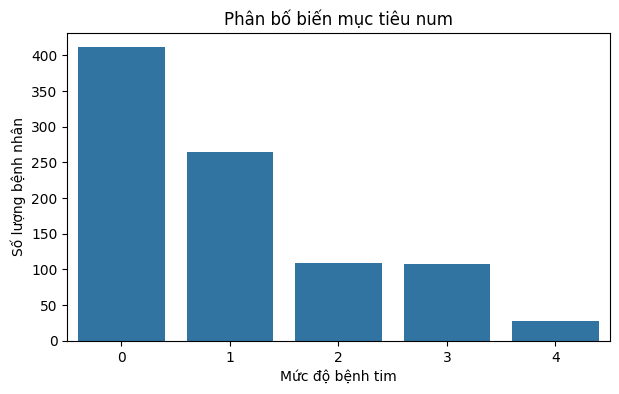

In [ ]:
# Vẽ biểu đồ phân bố biến mục tiêu num

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='num')
plt.title('Phân bố biến mục tiêu num')
plt.xlabel('Mức độ bệnh tim')
plt.ylabel('Số lượng bệnh nhân')
plt.show()

**Note:**

* Từ biểu đồ, ta thấy nhóm `num = 0` có số lượng bệnh nhân nhiều nhất, tương ứng với nhóm không mắc bệnh tim.

* Các nhóm `num = 1`, `num = 2`, `num = 3`, `num = 4` biểu diễn * các mức độ mắc bệnh tim khác nhau.  
Trong đó, nhóm `num = 4` có số lượng ít nhất.

Vì mục tiêu của dự án là dự đoán bệnh nhân có mắc bệnh tim hay không, ta sẽ chuyển `num` thành bài toán phân loại nhị phân.

### 3.3. Chuyển biến mục tiêu thành dạng nhị phân

Để đơn giản hóa bài toán, ta chuyển cột `num` thành biến nhị phân `target`:

- `target = 0`: Không mắc bệnh tim
- `target = 1`: Có mắc bệnh tim

Các giá trị `num` lớn hơn 0 đều được xem là có mắc bệnh tim.

In [ ]:
# Chuyển biến num thành biến nhị phân target

df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

# Kiểm tra phân bố target
df['target'].value_counts()

,count
target,
1,509
0,411


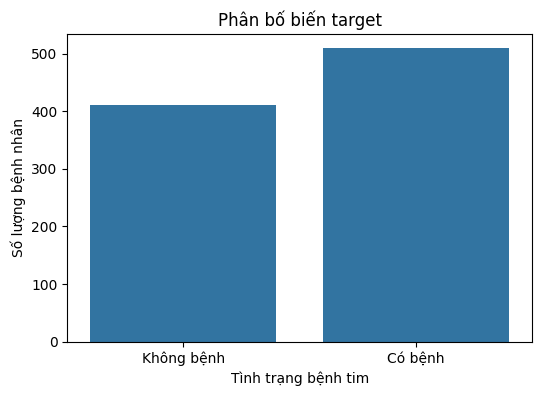

In [ ]:
# Vẽ biểu đồ phân bố biến target

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Phân bố biến target')
plt.xlabel('Tình trạng bệnh tim')
plt.ylabel('Số lượng bệnh nhân')
plt.xticks([0, 1], ['Không bệnh', 'Có bệnh'])
plt.show()

Sau khi chuyển đổi, bài toán trở thành bài toán phân loại nhị phân.

Biểu đồ cho thấy số lượng bệnh nhân có bệnh tim nhiều hơn số lượng bệnh nhân không mắc bệnh tim.  
Tuy nhiên, mức chênh lệch không quá lớn nên dữ liệu không bị mất cân bằng nghiêm trọng.

Điều này cho phép ta sử dụng các mô hình phân loại như Logistic Regression, KNN và Random Forest.

### 3.4. Phân tích đơn biến cho các biến số

Ở phần này, ta phân tích từng biến số riêng lẻ để hiểu phân bố dữ liệu.

Các biến số được phân tích gồm:

- `age`: Tuổi bệnh nhân
- `trestbps`: Huyết áp khi nghỉ
- `chol`: Cholesterol
- `thalch`: Nhịp tim tối đa đạt được
- `oldpeak`: Độ chênh ST khi vận động so với lúc nghỉ

Ta sử dụng histogram để quan sát phân bố và boxplot để phát hiện giá trị ngoại lai.

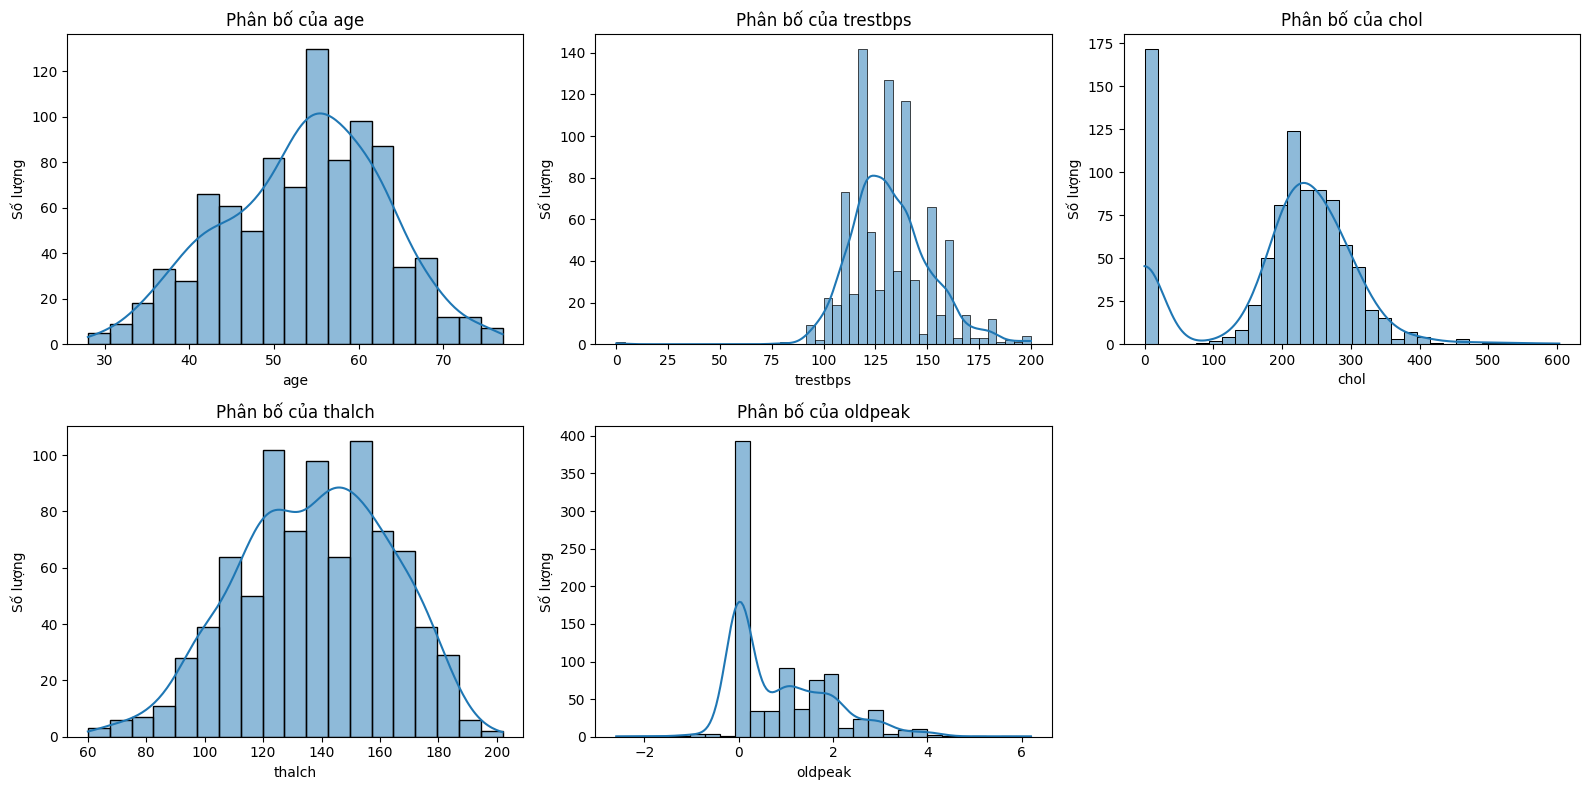

In [ ]:
# Vẽ histogram cho các biến số theo dạng n hàng và 3 cột

n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Phân bố của {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')

plt.tight_layout()
plt.show()

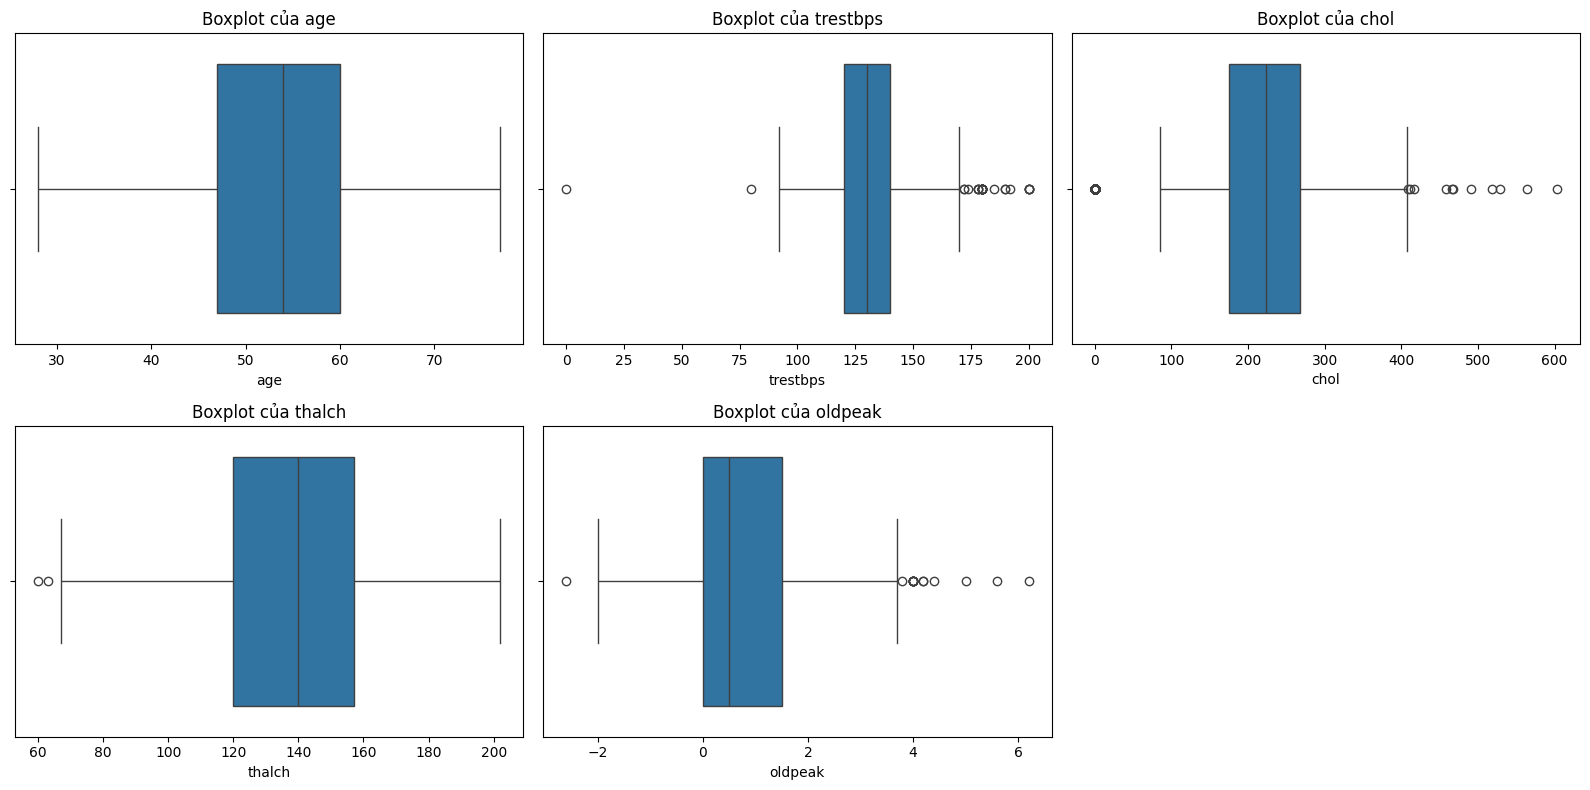

In [ ]:
# Vẽ boxplot cho các biến số để kiểm tra outliers

n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot của {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Từ các biểu đồ histogram và boxplot, ta có một số nhận xét:

- `age`: Tuổi bệnh nhân phân bố chủ yếu trong khoảng từ 45 đến 65 tuổi. Phân bố khá đều và không có outlier rõ ràng.

- `trestbps`: Huyết áp khi nghỉ tập trung nhiều trong khoảng 110 đến 150 mm Hg. Tuy nhiên, có một số giá trị bất thường, đặc biệt là giá trị bằng 0. Về mặt y tế, huyết áp bằng 0 là không hợp lý, nên có thể xem đây là giá trị lỗi hoặc missing value được mã hóa bằng 0.

- `chol`: Cholesterol tập trung chủ yếu trong khoảng 180 đến 300 mg/dl. Biểu đồ cho thấy có nhiều giá trị bằng 0, đây cũng là giá trị không hợp lý về mặt y tế. Ngoài ra, boxplot cho thấy có một số outliers ở vùng cholesterol cao.

- `thalch`: Nhịp tim tối đa đạt được phân bố chủ yếu trong khoảng 100 đến 180. Biến này có dạng phân bố tương đối gần chuẩn, tuy nhiên vẫn có một vài giá trị thấp bất thường.

- `oldpeak`: Phần lớn giá trị tập trung quanh 0, nhưng có một số giá trị cao hơn nhiều so với phần còn lại. Điều này cho thấy biến `oldpeak` có phân bố lệch phải và tồn tại một số outliers.

Nhìn chung, các biến số có phân bố khác nhau và một số biến có giá trị bất thường.  
Đặc biệt, `trestbps` và `chol` có giá trị bằng 0, cần được xử lý ở bước tiền xử lý dữ liệu trước khi huấn luyện mô hình.

### 3.5. Phân tích đơn biến cho các biến phân loại

Ở phần này, ta sử dụng biểu đồ cột để xem tần suất xuất hiện của từng nhóm giá trị trong các biến phân loại.

Các biến phân loại gồm:

- `sex`
- `dataset`
- `cp`
- `fbs`
- `restecg`
- `exang`
- `slope`
- `ca`
- `thal`

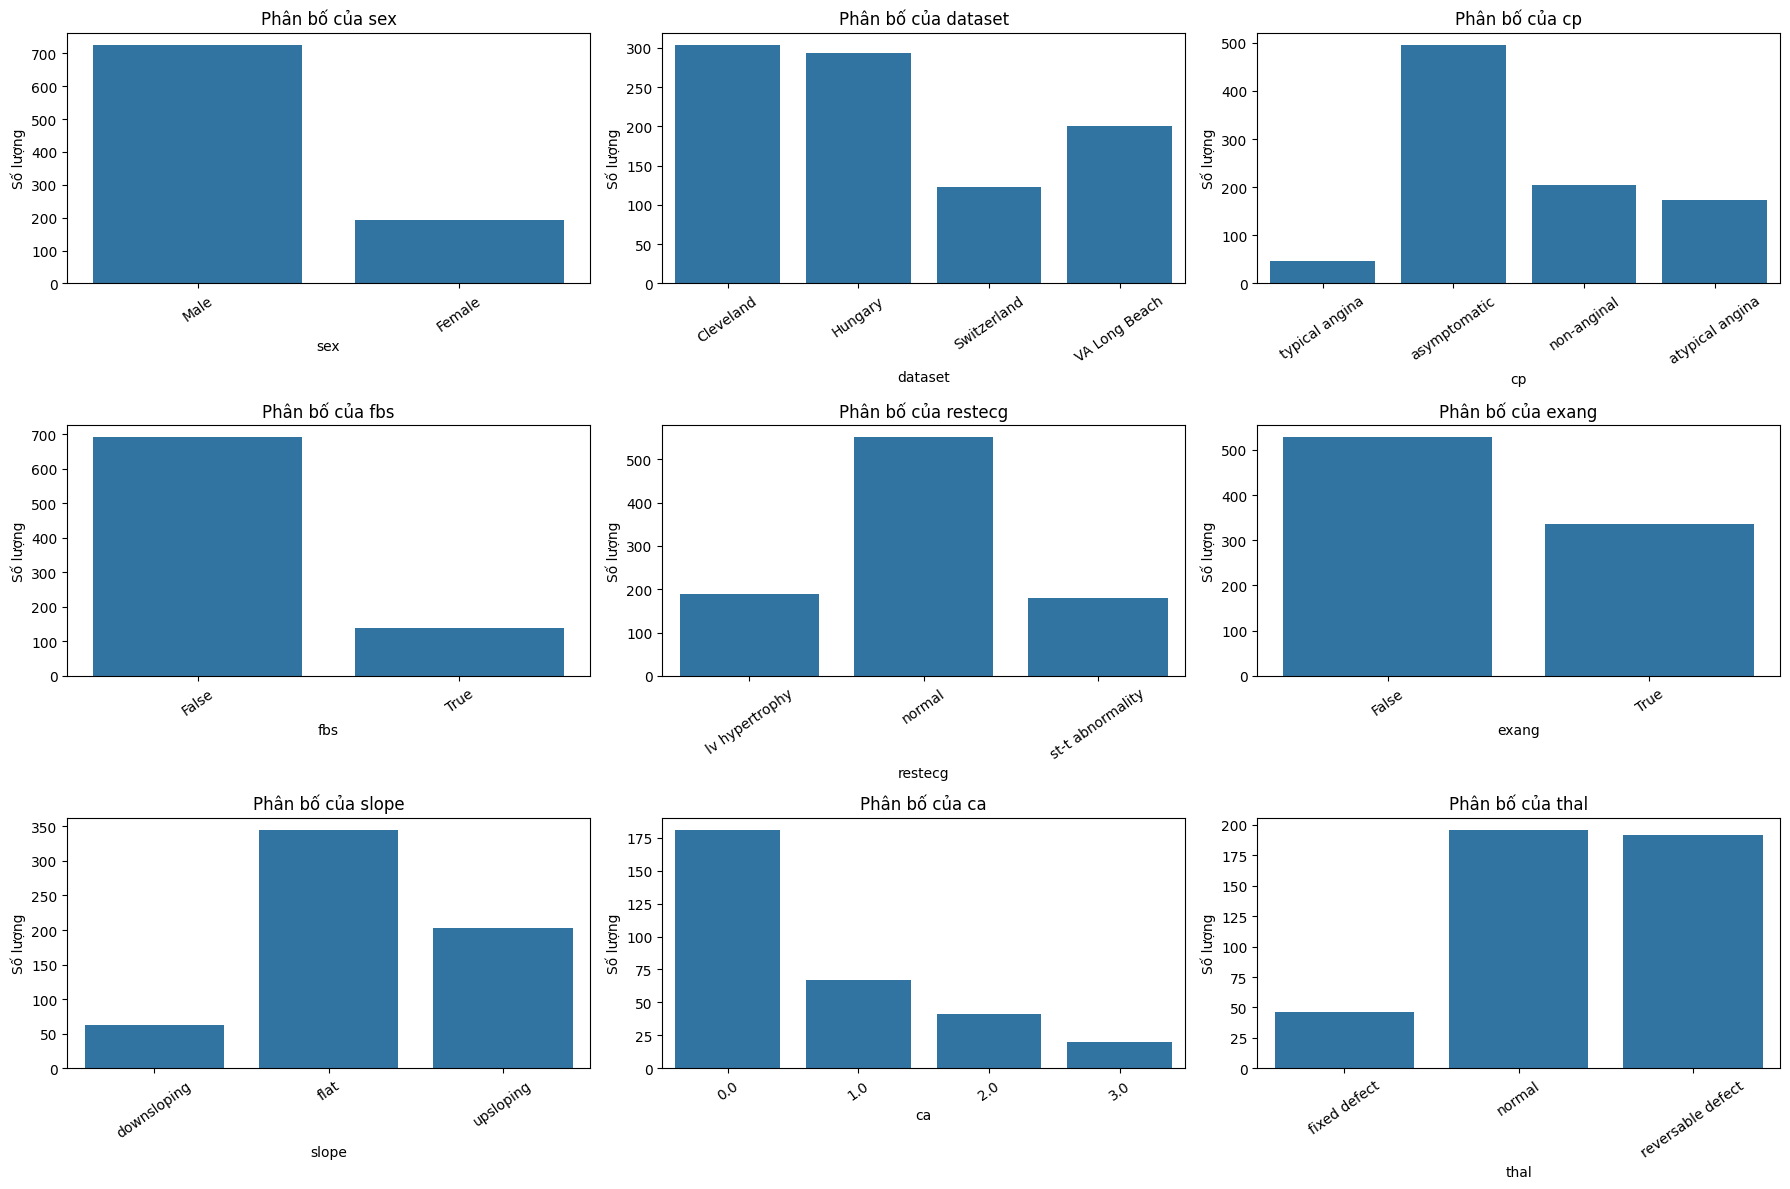

In [ ]:
# Vẽ biểu đồ cột cho các biến phân loại theo dạng n hàng và 3 cột

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Phân bố của {col}')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

Từ các biểu đồ cột của các biến phân loại, ta có một số nhận xét:

- `sex`: Số lượng bệnh nhân nam nhiều hơn rõ rệt so với bệnh nhân nữ. Điều này cho thấy dữ liệu có sự chênh lệch về giới tính.

- `dataset`: Dữ liệu được thu thập từ 4 nguồn khác nhau gồm Cleveland, Hungary, Switzerland và VA Long Beach. Trong đó, Cleveland và Hungary có số lượng mẫu nhiều hơn.

- `cp`: Loại đau ngực `asymptomatic` xuất hiện nhiều nhất. Đây là nhóm bệnh nhân không có triệu chứng đau ngực rõ ràng, nhưng vẫn có thể liên quan đến bệnh tim.

- `fbs`: Phần lớn bệnh nhân có `fbs = False`, tức là đường huyết lúc đói không vượt quá 120 mg/dl.

- `restecg`: Kết quả điện tâm đồ `normal` chiếm nhiều nhất, trong khi hai nhóm còn lại là `lv hypertrophy` và `st-t abnormality` có số lượng thấp hơn.

- `exang`: Số bệnh nhân không bị đau thắt ngực do vận động (`False`) nhiều hơn nhóm có triệu chứng này (`True`).

- `slope`: Nhóm `flat` xuất hiện nhiều nhất, tiếp theo là `upsloping`, còn `downsloping` ít hơn.

- `ca`: Phần lớn giá trị là `0.0`, tức là không có mạch máu chính bị phát hiện qua fluoroscopy. Tuy nhiên, cột này có khá nhiều missing values nên cần xử lý cẩn thận ở bước tiền xử lý.

- `thal`: Hai nhóm `normal` và `reversable defect` xuất hiện nhiều, trong khi `fixed defect` ít hơn.

Nhìn chung, các biến phân loại có sự phân bố không đồng đều giữa các nhóm.  
Một số biến như `cp`, `exang`, `slope`, `ca` và `thal` có thể có liên quan đến tình trạng bệnh tim, nên sẽ được phân tích thêm với biến mục tiêu `target` ở phần phân tích đa biến.

### 3.6. Phân tích đa biến với biến mục tiêu

Sau khi đã phân tích từng biến riêng lẻ, ta tiếp tục xem mối quan hệ giữa các đặc trưng và biến mục tiêu `target`.

Mục tiêu là xem sự khác biệt giữa hai nhóm bệnh nhân:

- Không mắc bệnh tim
- Có mắc bệnh tim

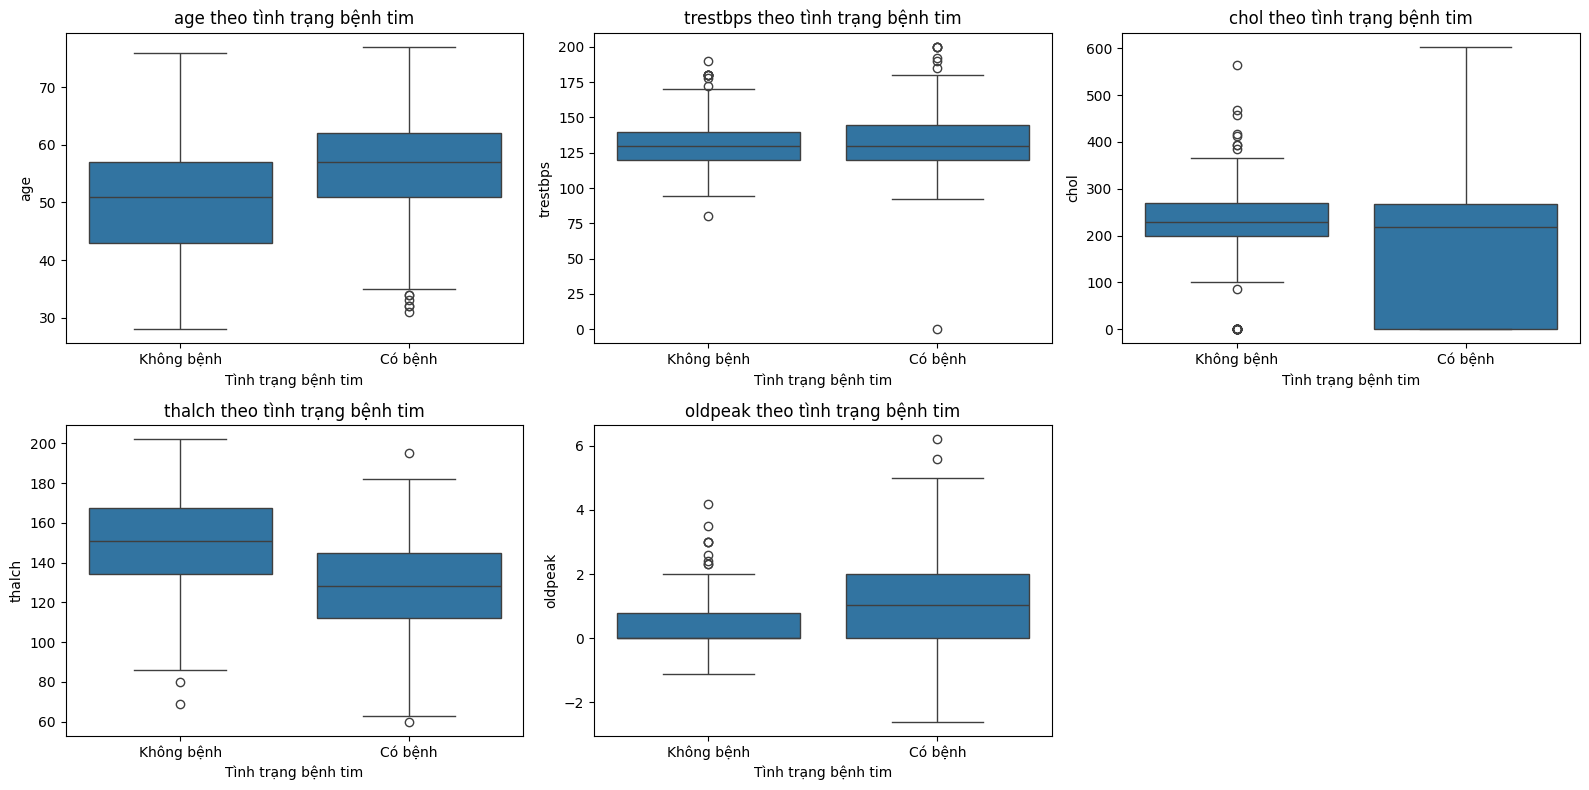

In [ ]:
# So sánh các biến số theo tình trạng bệnh tim

n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x='target', y=col)
    plt.title(f'{col} theo tình trạng bệnh tim')
    plt.xlabel('Tình trạng bệnh tim')
    plt.ylabel(col)
    plt.xticks([0, 1], ['Không bệnh', 'Có bệnh'])

plt.tight_layout()
plt.show()

**NOTE:**
- `age`: Nhóm bệnh nhân có bệnh tim có xu hướng lớn tuổi hơn nhóm không bệnh. Điều này cho thấy tuổi có thể là một yếu tố liên quan đến nguy cơ mắc bệnh tim.

- `trestbps`: Huyết áp khi nghỉ giữa hai nhóm không có sự khác biệt quá rõ ràng. Tuy nhiên, nhóm có bệnh tim xuất hiện một số giá trị bất thường, đặc biệt là giá trị bằng 0.

- `chol`: Cholesterol giữa hai nhóm có sự phân bố khá rộng. Nhóm có bệnh xuất hiện nhiều giá trị bằng 0, đây có thể là dữ liệu bất thường cần xử lý ở bước tiền xử lý.

- `thalch`: Nhóm không bệnh có nhịp tim tối đa đạt được cao hơn nhóm có bệnh. Đây có thể là một đặc trưng quan trọng vì người mắc bệnh tim thường có khả năng đạt nhịp tim tối đa thấp hơn.

- `oldpeak`: Nhóm có bệnh tim có giá trị `oldpeak` cao hơn nhóm không bệnh. Điều này cho thấy `oldpeak` có thể liên quan đến tình trạng bệnh tim.


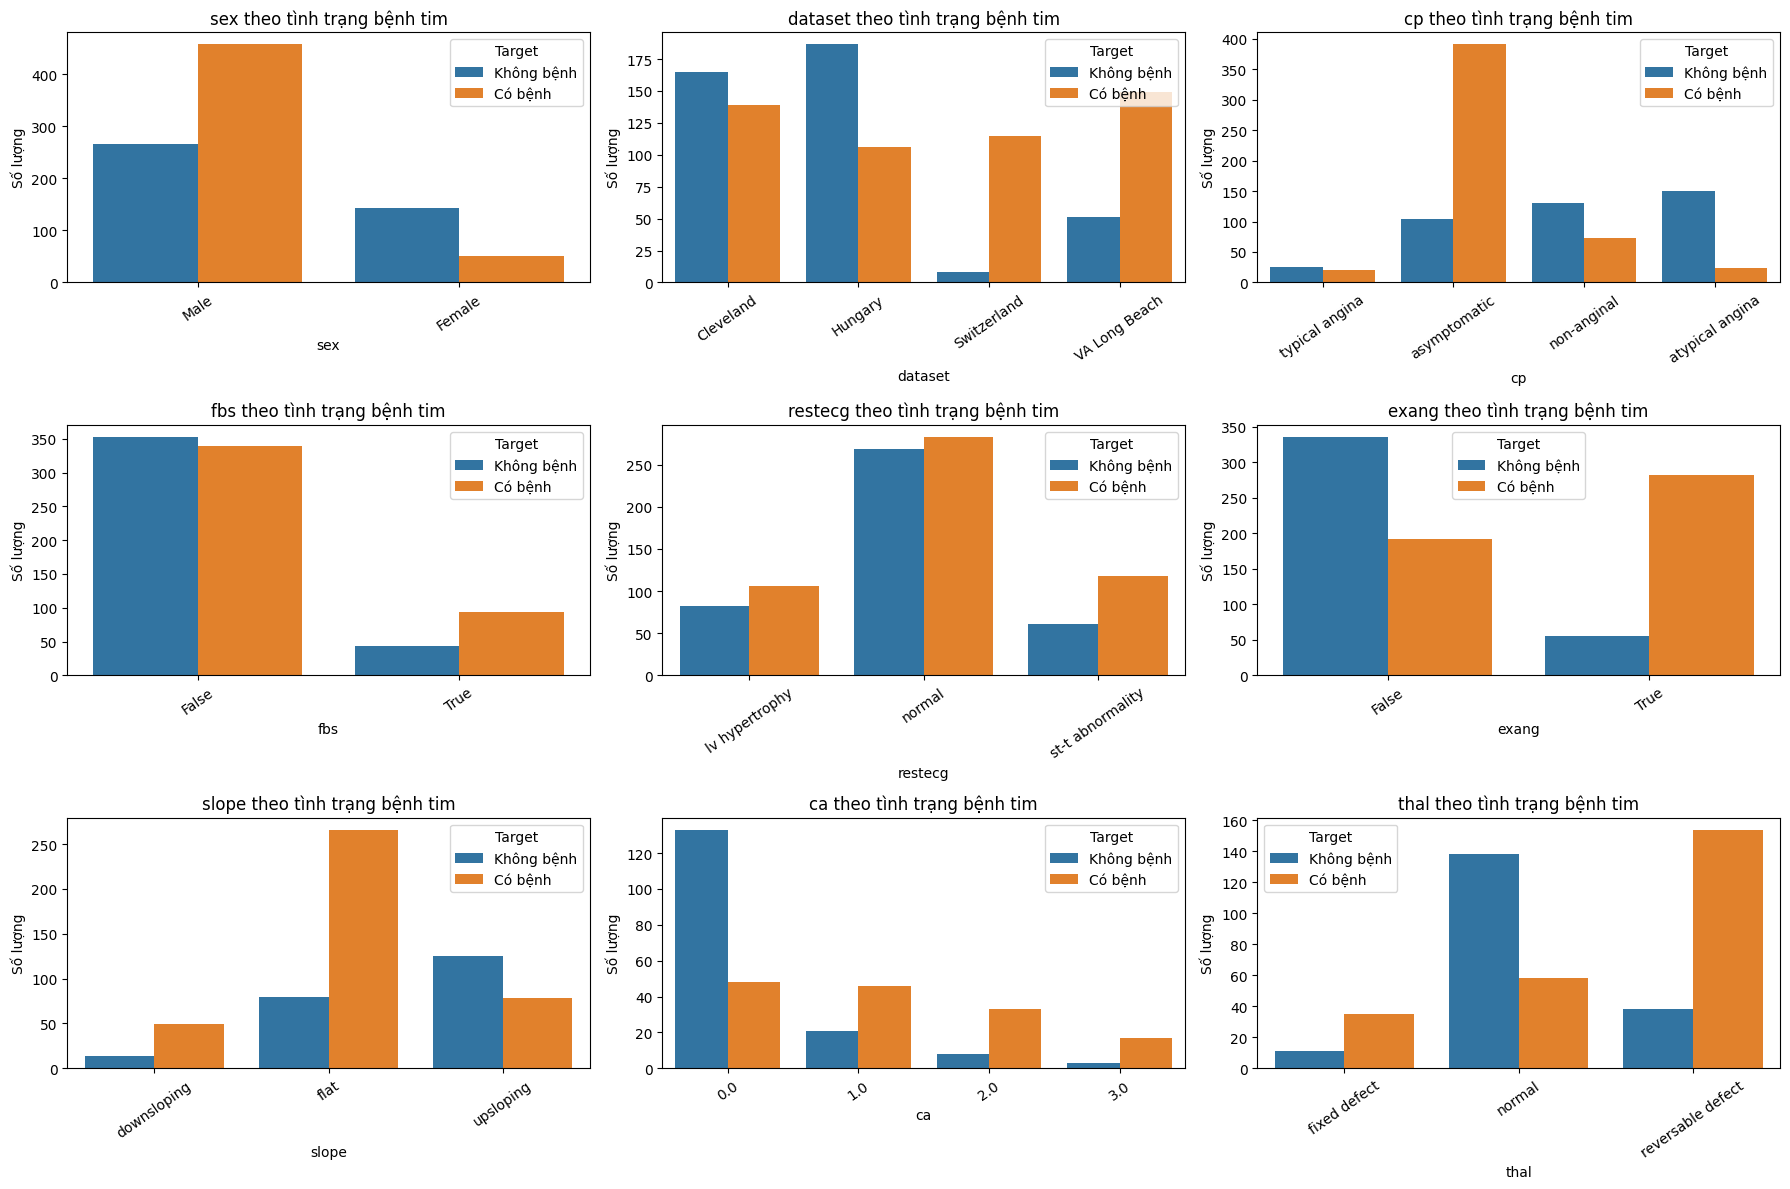

In [ ]:
# So sánh các biến phân loại theo tình trạng bệnh tim

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, hue='target')
    plt.title(f'{col} theo tình trạng bệnh tim')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=35)
    plt.legend(title='Target', labels=['Không bệnh', 'Có bệnh'])

plt.tight_layout()
plt.show()

**NOTE:**
- `sex`: Nam giới có số lượng mắc bệnh tim cao hơn nữ giới trong dataset này.

- `dataset`: Tỷ lệ có bệnh và không bệnh khác nhau giữa các nguồn dữ liệu. Điều này cho thấy nguồn thu thập dữ liệu có thể ảnh hưởng đến phân bố của biến mục tiêu.

- `cp`: Nhóm `asymptomatic` có số lượng bệnh nhân mắc bệnh tim rất cao. Đây là một biến có vẻ liên quan mạnh đến tình trạng bệnh tim.

- `fbs`: Sự khác biệt giữa hai nhóm `True` và `False` không quá rõ ràng, nên biến này có thể không phải là yếu tố phân biệt mạnh.

- `restecg`: Các nhóm trong `restecg` có sự chênh lệch giữa có bệnh và không bệnh, nhưng mức độ khác biệt không quá lớn.

- `exang`: Nhóm có đau thắt ngực do vận động (`True`) có số lượng bệnh nhân mắc bệnh tim cao hơn rõ rệt. Đây có thể là một đặc trưng quan trọng.

- `slope`: Nhóm `flat` có số lượng bệnh nhân mắc bệnh tim cao hơn nhiều so với không bệnh. Biến này có thể có liên quan đến bệnh tim.

- `ca`: Khi giá trị `ca` tăng từ 1 đến 3, số lượng bệnh nhân có bệnh tim có xu hướng cao hơn nhóm không bệnh. Tuy nhiên, cột này có nhiều missing values nên cần xử lý cẩn thận.

- `thal`: Nhóm `reversable defect` có số lượng bệnh nhân mắc bệnh tim cao hơn rõ rệt, trong khi nhóm `normal` có nhiều bệnh nhân không bệnh hơn.

### 3.7. Ma trận tương quan

Ma trận tương quan được sử dụng để xem mức độ liên hệ tuyến tính giữa các biến số và biến mục tiêu `target`.

Giá trị tương quan càng gần 1 hoặc -1 thì mối quan hệ tuyến tính càng mạnh.  
Giá trị gần 0 cho thấy mối quan hệ tuyến tính yếu.

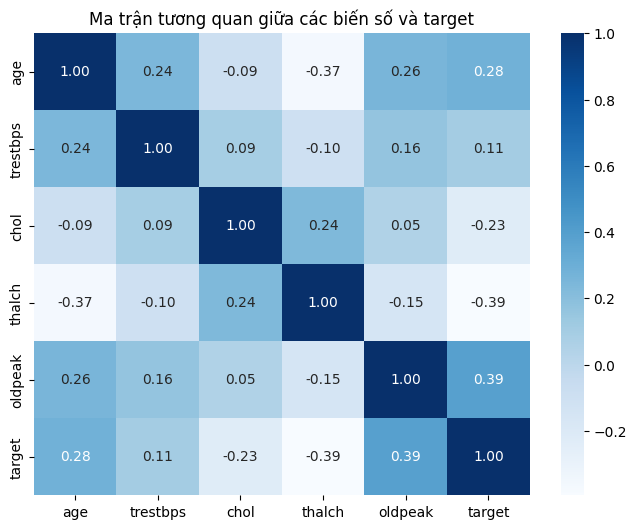

In [ ]:
# Vẽ ma trận tương quan giữa các biến số và target

corr_cols = numeric_features + ['target']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số và target')
plt.show()

**NOTE:**

- `oldpeak` có tương quan dương với `target` khoảng **0.39**. Điều này cho thấy khi `oldpeak` tăng, khả năng bệnh nhân mắc bệnh tim cũng có xu hướng tăng.

- `thalch` có tương quan âm với `target` khoảng **-0.39**. Điều này cho thấy bệnh nhân có nhịp tim tối đa thấp hơn thường có xu hướng mắc bệnh tim nhiều hơn.

- `age` có tương quan dương với `target` khoảng **0.28**, nghĩa là tuổi càng cao thì nguy cơ mắc bệnh tim có xu hướng tăng.

- `chol` có tương quan âm với `target` khoảng **-0.23**. Tuy nhiên, kết quả này cần được xem xét cẩn thận vì cột `chol` có nhiều giá trị bằng 0, có thể là dữ liệu bất thường.

- `trestbps` có tương quan khá thấp với `target`, khoảng **0.11**, nên mối quan hệ tuyến tính giữa huyết áp khi nghỉ và bệnh tim không rõ ràng trong dataset này.

Nhìn chung, các biến `oldpeak`, `thalch` và `age` có mức tương quan đáng chú ý hơn với biến mục tiêu.  
Tuy nhiên, tương quan chỉ phản ánh mối quan hệ tuyến tính, nên không thể kết luận hoàn toàn biến nào quan trọng nhất chỉ dựa vào ma trận này.  
Ta vẫn cần huấn luyện mô hình và phân tích thêm feature importance ở các bước sau.

### 3.8. Phân tích mối quan hệ với tuổi

Ở phần này, ta phân tích mối quan hệ giữa tuổi (`age`) với một số biến số quan trọng như:

- `chol`: Cholesterol
- `trestbps`: Huyết áp khi nghỉ
- `thalch`: Nhịp tim tối đa đạt được

Scatter plot kèm đường hồi quy giúp quan sát xu hướng tuyến tính giữa tuổi và các chỉ số y tế này.

Màu sắc của các điểm dữ liệu thể hiện tình trạng bệnh tim:

- `0`: Không mắc bệnh tim
- `1`: Có mắc bệnh tim

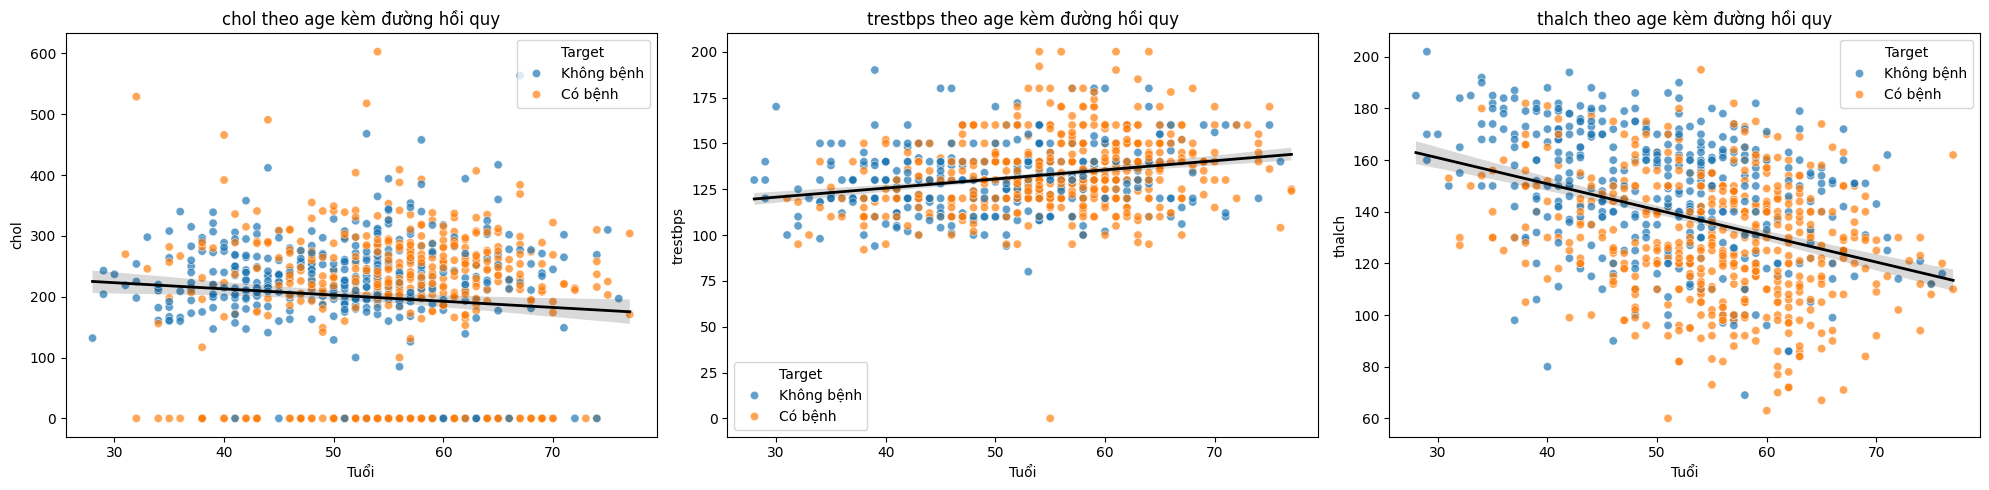

In [ ]:
# Phân tích mối quan hệ giữa age và một số biến số khác
# Scatter plot theo target + đường hồi quy chung

age_related_features = ['chol', 'trestbps', 'thalch']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col in zip(axes, age_related_features):

    sns.scatterplot(
        data=df,
        x='age',
        y=col,
        hue='target',
        hue_order=[0, 1],
        palette={0: 'tab:blue', 1: 'tab:orange'},
        alpha=0.7,
        ax=ax
    )

    sns.regplot(
        data=df,
        x='age',
        y=col,
        scatter=False,
        color='black',
        line_kws={'linewidth': 2},
        ax=ax
    )

    ax.set_title(f'{col} theo age kèm đường hồi quy')
    ax.set_xlabel('Tuổi')
    ax.set_ylabel(col)

    # Sửa legend cho đúng màu
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=['Không bệnh', 'Có bệnh'],
        title='Target'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Tính tương quan giữa age và một số biến số

age_corr_cols = ['age', 'chol', 'trestbps', 'thalch']

age_corr = df[age_corr_cols].corr(numeric_only=True)['age'].drop('age')

age_corr

,age
chol,-0.086234
trestbps,0.244253
thalch,-0.365778


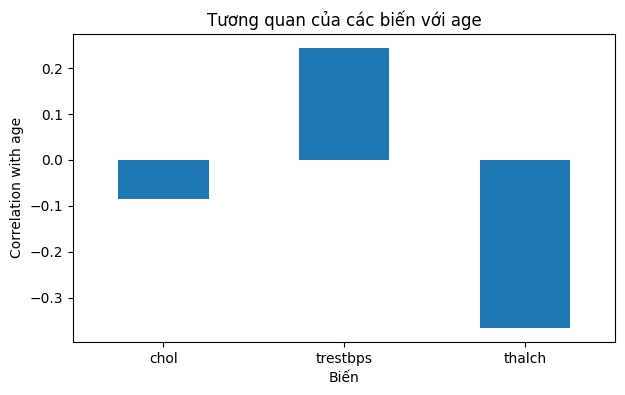

In [ ]:
# Vẽ biểu đồ tương quan của các biến với age

plt.figure(figsize=(7, 4))
age_corr.plot(kind='bar')
plt.title('Tương quan của các biến với age')
plt.xlabel('Biến')
plt.ylabel('Correlation with age')
plt.xticks(rotation=0)
plt.show()

Các biểu đồ scatter plot kèm đường hồi quy cho thấy mối quan hệ giữa tuổi (`age`) và một số chỉ số y tế như `chol`, `trestbps`, `thalch`.

- Với `chol`, đường hồi quy có xu hướng giảm nhẹ theo tuổi. Tuy nhiên, biểu đồ có nhiều giá trị cholesterol bằng 0, đây có thể là dữ liệu bất thường nên kết quả cần được xem xét cẩn thận.

- Với `trestbps`, đường hồi quy có xu hướng tăng nhẹ khi tuổi tăng. Điều này cho thấy bệnh nhân lớn tuổi có thể có huyết áp khi nghỉ cao hơn.

- Với `thalch`, đường hồi quy giảm khá rõ khi tuổi tăng. Điều này cho thấy bệnh nhân lớn tuổi thường có nhịp tim tối đa đạt được thấp hơn.

Biểu đồ tương quan bên dưới cũng cho thấy `thalch` có tương quan âm mạnh nhất với `age`, trong khi `trestbps` có tương quan dương nhẹ với `age`.

Ngoài ra, các điểm dữ liệu của hai nhóm có bệnh và không bệnh vẫn còn chồng lấn nhiều, nên không thể phân loại bệnh tim chỉ dựa trên tuổi và một biến số đơn lẻ.

## 4. Prepare the Data for Machine Learning

Sau bước EDA, ta chuẩn bị dữ liệu cho mô hình Machine Learning.

Ở bước này, ta sẽ:
- Chuyển bài toán thành binary classification
- Tạo biến target từ cột `num`
- Tách dữ liệu thành features `X` và label `y`
- Chia dữ liệu thành training set và test set

Lưu ý: các bước xử lý như fill missing value, encoding và scaling sẽ được đưa vào pipeline để tránh data leakage.

In [ ]:
df_model = df.copy()

df_model['target'] = df_model['num'].apply(lambda x: 0 if x == 0 else 1)

df_model['trestbps'] = df_model['trestbps'].replace(0, np.nan)
df_model['chol'] = df_model['chol'].replace(0, np.nan)
df_model.loc[df_model['oldpeak'] < 0, 'oldpeak'] = np.nan

df_model[['num', 'target']].head()

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [ ]:
X = df_model.drop(columns=['id', 'dataset', 'num', 'target'])
y = df_model['target']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 13)
y shape: (920,)


## 5. Train/Test Split

Ta chia dữ liệu thành training set và test set.

Training set dùng để huấn luyện mô hình và cross-validation.  
Test set chỉ dùng một lần cuối cùng để đánh giá mô hình sau khi đã chọn và tinh chỉnh xong.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (736, 13)
X_test: (184, 13)
y_train: (736,)
y_test: (184,)


## 6. Preprocessing Pipeline

Ta xây dựng preprocessing pipeline để xử lý dữ liệu trước khi đưa vào mô hình.

Pipeline gồm:
- Numeric features: xử lý missing value bằng median, sau đó chuẩn hóa bằng StandardScaler
- Categorical features: xử lý missing value bằng mode, sau đó mã hóa bằng OneHotEncoder

Pipeline chỉ được fit trên training set. Test set chỉ được transform bằng pipeline đã học từ training set.

In [ ]:
numeric_features = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal'
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

## 8. Select and Train Models

Ta sẽ thử 3 mô hình:

- Logistic Regression: baseline model, đơn giản và dễ giải thích
- KNN: mô hình dựa trên khoảng cách
- Random Forest: ensemble model, có khả năng học quan hệ phi tuyến tốt hơn

Mỗi model sẽ được gắn với cùng một preprocessing pipeline để đảm bảo xử lý dữ liệu nhất quán.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

## 9. Better Evaluation Using Cross-Validation

Ta dùng K-Fold Cross-Validation trên training set để đánh giá mô hình ổn định hơn.

Test set chưa được sử dụng ở bước này.  
Test set chỉ dùng sau khi đã chọn được mô hình cuối cùng.

In [ ]:
from sklearn.model_selection import cross_validate
import pandas as pd

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = []

for model_name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        clf,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

    cv_results.append({
        'Model': model_name,
        'Train Accuracy': scores['train_accuracy'].mean(),
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1': scores['test_f1'].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Train Accuracy,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,0.825068,0.817908,0.824292,0.852304,0.836992
1,KNN,0.862096,0.808411,0.804238,0.864679,0.832863
2,Random Forest,1.000000,0.808393,0.809236,0.854833,0.831046


In [ ]:
cv_results_df = cv_results_df.sort_values(
    by=['CV F1', 'CV Recall'],
    ascending=False
)

cv_results_df

,Model,Train Accuracy,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,0.825068,0.817908,0.824292,0.852304,0.836992
1,KNN,0.862096,0.808411,0.804238,0.864679,0.832863
2,Random Forest,1.000000,0.808393,0.809236,0.854833,0.831046


## 10. Train Best Baseline Model

Sau khi so sánh bằng cross-validation, ta chọn mô hình có F1-score tốt nhất để train lại trên toàn bộ training set.

In [ ]:
best_model_name = cv_results_df.iloc[0]['Model']
best_base_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_base_model)
])

best_pipeline.fit(X_train, y_train)

print("Best baseline model:", best_model_name)

Best baseline model: Logistic Regression


## 11. Fine-Tune Random Forest

Ta dùng GridSearchCV để tìm bộ hyperparameter tốt hơn cho Random Forest.

Random Forest được chọn vì đây là mô hình ensemble, thường ổn định và có khả năng học quan hệ phi tuyến tốt.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 3, 5, 7, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV F1-score:")
print(grid_search.best_score_)

Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best CV F1-score:
0.8444510887869032


In [ ]:
final_model = grid_search.best_estimator_

In [ ]:
tuned_scores = cross_validate(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=True
)

tuned_rf_result = pd.DataFrame([{
    'Model': 'Tuned Random Forest',
    'Train Accuracy': tuned_scores['train_accuracy'].mean(),
    'CV Accuracy': tuned_scores['test_accuracy'].mean(),
    'CV Precision': tuned_scores['test_precision'].mean(),
    'CV Recall': tuned_scores['test_recall'].mean(),
    'CV F1': tuned_scores['test_f1'].mean()
}])

comparison_df = pd.concat(
    [cv_results_df, tuned_rf_result],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    by=['CV F1', 'CV Recall'],
    ascending=False
)

comparison_df

,Model,Train Accuracy,CV Accuracy,CV Precision,CV Recall,CV F1
3,Tuned Random Forest,0.917119,0.826062,0.833059,0.857302,0.844451
0,Logistic Regression,0.825068,0.817908,0.824292,0.852304,0.836992
1,KNN,0.862096,0.808411,0.804238,0.864679,0.832863
2,Random Forest,1.000000,0.808393,0.809236,0.854833,0.831046


## 12. Evaluate Final Model on Test Set

Sau khi đã chọn và tinh chỉnh mô hình, ta đánh giá lần cuối trên test set.

Test set chỉ được sử dụng ở bước cuối cùng này để mô phỏng dữ liệu mới trong thực tế.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

test_results = []

# Các model baseline đã khai báo trước đó
models_for_test = {
    "Logistic Regression": models["Logistic Regression"],
    "KNN": models["KNN"],
    "Random Forest": models["Random Forest"]
}

for model_name, model in models_for_test.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    test_results.append({
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred)
    })

# Thêm Tuned Random Forest
y_pred_tuned = final_model.predict(X_test)

test_results.append({
    "Model": "Tuned Random Forest",
    "Test Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Test Precision": precision_score(y_test, y_pred_tuned),
    "Test Recall": recall_score(y_test, y_pred_tuned),
    "Test F1": f1_score(y_test, y_pred_tuned)
})

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by=["Test F1", "Test Recall"],
    ascending=False
)

test_results_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.820652,0.828571,0.852941,0.840580
3,Tuned Random Forest,0.815217,0.814815,0.862745,0.838095
2,Random Forest,0.804348,0.817308,0.833333,0.825243
1,KNN,0.788043,0.788991,0.843137,0.815166


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_model = grid_search.best_estimator_

y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_accuracy)
print("Final Test Precision:", test_precision)
print("Final Test Recall:", test_recall)
print("Final Test F1-score:", test_f1)

Final Test Accuracy: 0.8152173913043478
Final Test Precision: 0.8148148148148148
Final Test Recall: 0.8627450980392157
Final Test F1-score: 0.8380952380952381


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_test_pred,
    target_names=['No Heart Disease', 'Heart Disease']
))

                  precision    recall  f1-score   support

No Heart Disease       0.82      0.76      0.78        82
   Heart Disease       0.81      0.86      0.84       102

        accuracy                           0.82       184
       macro avg       0.82      0.81      0.81       184
    weighted avg       0.82      0.82      0.81       184



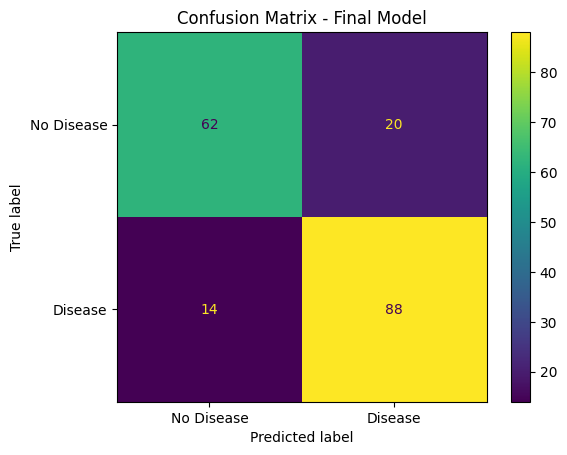

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disease', 'Disease']
)

disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.show()

## 14. Analyze the Best Model

Ta phân tích feature importance để xem những đặc trưng nào ảnh hưởng nhiều đến dự đoán của mô hình.

In [ ]:
# Lấy tên feature sau khi qua preprocessing

feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Lấy feature importance từ Random Forest

importances = final_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
7,cat__cp_asymptomatic,0.142427
0,num__age,0.102442
3,num__thalch,0.096843
4,num__oldpeak,0.092602
16,cat__exang_False,0.087968
2,num__chol,0.068351
17,cat__exang_True,0.066711
8,cat__cp_atypical angina,0.055086
1,num__trestbps,0.050009
5,cat__sex_Female,0.036005


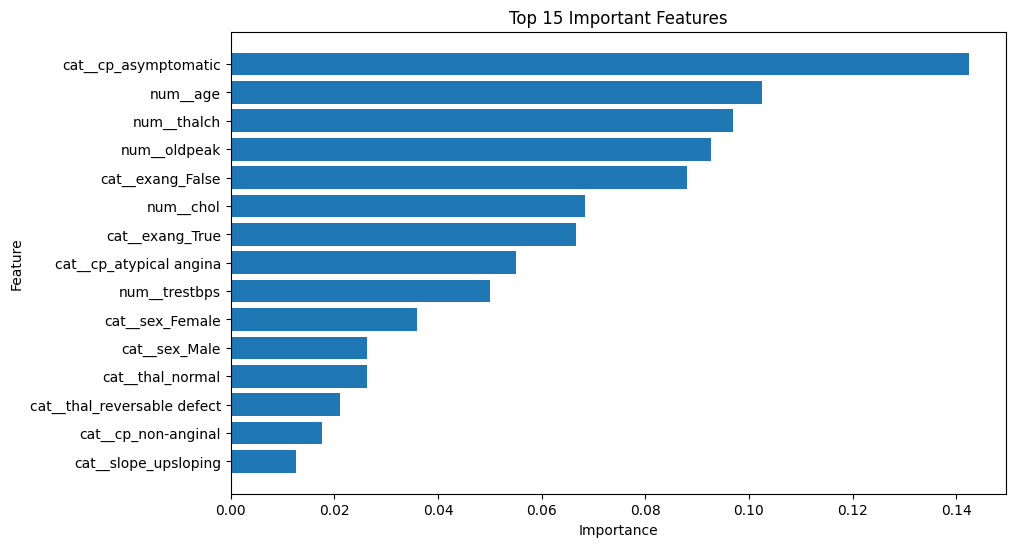

In [ ]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
import joblib

joblib.dump(final_model, "heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("heart_disease_model.pkl")

sample_pred = loaded_model.predict(X_test.iloc[:5])

print(sample_pred)

[0 1 1 1 1]
